<a href="https://colab.research.google.com/github/mhabibier/Developing-RTOS-Traffic-System/blob/main/02_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Supervised Learning

**Nama:** Muhammad Habibie Rabbani  
**NIM:** 101032300005  
**Kelas:** TK-47-04  

Notebook ini berisi reproduksi kode dan penjelasan teori dari Chapter 2
buku *Introduction to Machine Learning with Python* karya Andreas C.
Müller dan Sarah Guido.

## 1. Tujuan Pembelajaran

Pada chapter ini, saya mempelajari:

1. Perbedaan classification dan regression.
2. Konsep generalization, overfitting, dan underfitting.
3. Cara kerja K-Nearest Neighbors.
4. Linear models untuk classification dan regression.
5. Naive Bayes classifier.
6. Decision tree dan ensemble models.
7. Support Vector Machine.
8. Neural network.
9. Cara membandingkan kelebihan dan kekurangan setiap algoritma.
10. Cara memilih model supervised learning yang sesuai.

In [1]:
!pip install -q mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 12.6 MB/s eta 0:00:00


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import mglearn

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

print("Python       :", sys.version)
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)

Python       : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy        : 2.1.3
Pandas       : 2.2.3
Scikit-learn : 1.6.1


## 2. Supervised Learning

Supervised learning adalah metode machine learning yang mempelajari
hubungan antara data masukan dan target berdasarkan data berlabel.

Data masukan disebut fitur dan biasanya dilambangkan dengan `X`.
Target atau jawaban yang ingin diprediksi biasanya dilambangkan dengan
`y`.

Supervised learning terdiri dari dua jenis utama:

1. **Classification**, digunakan ketika target berupa kategori.
2. **Regression**, digunakan ketika target berupa angka kontinu.

### 2.1 Classification

Classification digunakan untuk memprediksi kelas atau kategori.

Contoh:

- Email spam atau bukan spam.
- Slot parkir kosong atau terisi.
- Transaksi normal atau mencurigakan.
- Bunga termasuk Setosa, Versicolor, atau Virginica.

Pada binary classification terdapat dua kelas, sedangkan multiclass
classification mempunyai lebih dari dua kelas.

### 2.2 Regression

Regression digunakan untuk memprediksi nilai numerik kontinu.

Contoh:

- Prediksi harga rumah.
- Prediksi suhu.
- Prediksi jumlah kendaraan.
- Prediksi kebutuhan kapasitas parkir.

Perbedaan utamanya terletak pada hasil prediksi. Classification
menghasilkan kategori, sedangkan regression menghasilkan angka.

## 3. Generalization, Overfitting, dan Underfitting

### 3.1 Generalization

Generalization adalah kemampuan model untuk memberikan prediksi yang
baik pada data baru yang belum pernah dilihat ketika proses training.

### 3.2 Overfitting

Overfitting terjadi ketika model terlalu menyesuaikan diri dengan data
training. Model menghasilkan nilai training yang sangat tinggi, tetapi
memberikan hasil buruk pada data testing.

Model yang terlalu kompleks lebih berisiko mengalami overfitting.

### 3.3 Underfitting

Underfitting terjadi ketika model terlalu sederhana sehingga tidak
mampu mempelajari pola penting dalam data. Akibatnya, performa pada data
training dan testing sama-sama rendah.

Model machine learning yang baik harus memperoleh keseimbangan antara
underfitting dan overfitting agar mampu melakukan generalisasi.

## 4. Contoh Dataset Classification

Dataset Forge merupakan dataset sintetis dua dimensi yang digunakan
untuk memperlihatkan cara kerja algoritma classification.

Dataset ini mempunyai dua fitur dan dua kelas. Setiap titik
merepresentasikan satu data, sedangkan warna dan bentuk titik
menunjukkan kelasnya.

In [3]:
X_forge, y_forge = mglearn.datasets.make_forge()

print("Ukuran fitur:", X_forge.shape)
print("Ukuran target:", y_forge.shape)
print("Kelas:", np.unique(y_forge))

Ukuran fitur: (26, 2)
Ukuran target: (26,)
Kelas: [0 1]


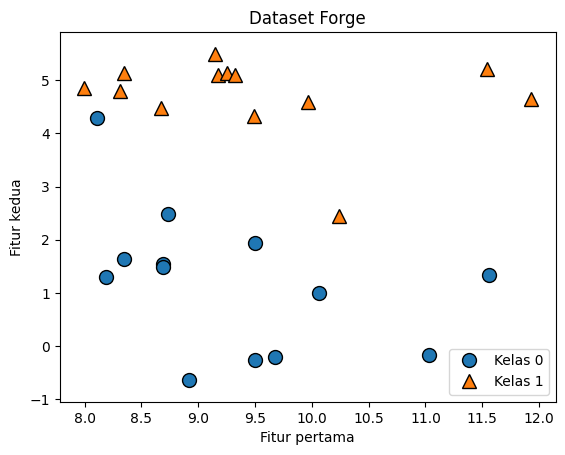

In [4]:
mglearn.discrete_scatter(
    X_forge[:, 0],
    X_forge[:, 1],
    y_forge
)

plt.legend(
    ["Kelas 0", "Kelas 1"],
    loc=4
)

plt.xlabel("Fitur pertama")
plt.ylabel("Fitur kedua")
plt.title("Dataset Forge")
plt.show()

### Analisis Dataset Forge

Dataset Forge berisi dua fitur dan dua kelas sehingga termasuk binary
classification. Setiap titik merepresentasikan satu sampel data.

Beberapa data dari kedua kelas berada berdekatan. Kondisi ini membuat
model perlu menentukan batas keputusan untuk memisahkan kelas 0 dan
kelas 1.

## 5. Contoh Dataset Regression

Dataset Wave adalah dataset sintetis yang digunakan untuk memperlihatkan
masalah regression.

Dataset mempunyai satu fitur sebagai masukan dan target numerik kontinu
sebagai keluaran.

In [5]:
X_wave, y_wave = mglearn.datasets.make_wave(
    n_samples=40
)

print("Ukuran fitur:", X_wave.shape)
print("Ukuran target:", y_wave.shape)

Ukuran fitur: (40, 1)
Ukuran target: (40,)


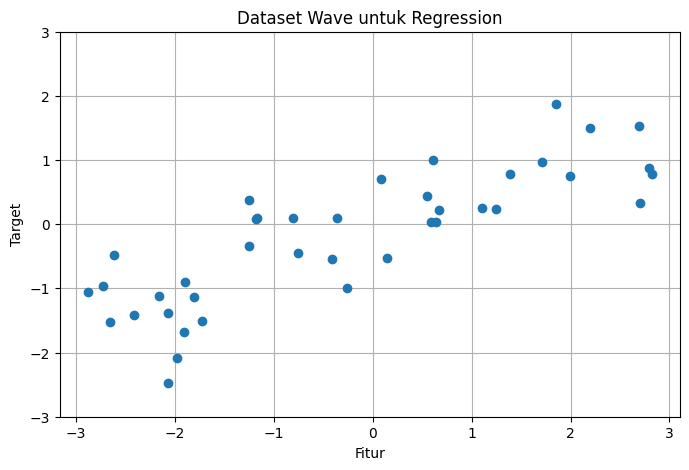

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    X_wave,
    y_wave,
    "o"
)

plt.ylim(-3, 3)
plt.xlabel("Fitur")
plt.ylabel("Target")
plt.title("Dataset Wave untuk Regression")
plt.grid(True)
plt.show()

### Analisis Dataset Wave

Dataset Wave mempunyai satu fitur dan target berbentuk nilai numerik
kontinu. Oleh karena itu, dataset ini digunakan untuk permasalahan
regression.

Titik-titik data menunjukkan adanya hubungan antara fitur dan target,
tetapi terdapat variasi atau noise yang menyebabkan data tidak
membentuk garis yang sempurna.

## 6. K-Nearest Neighbors Classification

K-Nearest Neighbors atau KNN menentukan kelas data baru berdasarkan
kelas data-data training yang paling dekat.

Tahapan kerja KNN:

1. Menghitung jarak data baru dengan seluruh data training.
2. Memilih sejumlah `k` data dengan jarak paling dekat.
3. Menghitung kelas yang paling banyak muncul.
4. Menggunakan kelas mayoritas sebagai hasil prediksi.

Jika `n_neighbors=1`, model hanya menggunakan satu tetangga terdekat.
Jika `n_neighbors` lebih besar, prediksi ditentukan berdasarkan suara
mayoritas dari beberapa tetangga.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_forge,
    y_forge,
    test_size=0.25,
    random_state=0
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (19, 2)
Ukuran X_test : (7, 2)
Ukuran y_train: (19,)
Ukuran y_test : (7,)


In [8]:
knn_classifier = KNeighborsClassifier(
    n_neighbors=3
)

knn_classifier.fit(
    X_train,
    y_train
)

print("Model KNN classifier berhasil dilatih.")

Model KNN classifier berhasil dilatih.


In [9]:
y_pred = knn_classifier.predict(X_test)

print("Hasil prediksi :", y_pred)
print("Target aktual  :", y_test)

Hasil prediksi : [1 0 1 0 1 0 0]
Target aktual  : [1 0 1 0 1 1 0]


In [10]:
akurasi = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Akurasi model: {akurasi:.3f}"
)

Akurasi model: 0.857


### Analisis Hasil KNN Classification

Model KNN dilatih menggunakan tiga tetangga terdekat. Hasil prediksi
kemudian dibandingkan dengan target sebenarnya dari data testing.

Nilai akurasi menunjukkan perbandingan jumlah prediksi yang benar
terhadap seluruh data testing. Semakin mendekati 1, semakin banyak data
yang berhasil diklasifikasikan dengan benar.

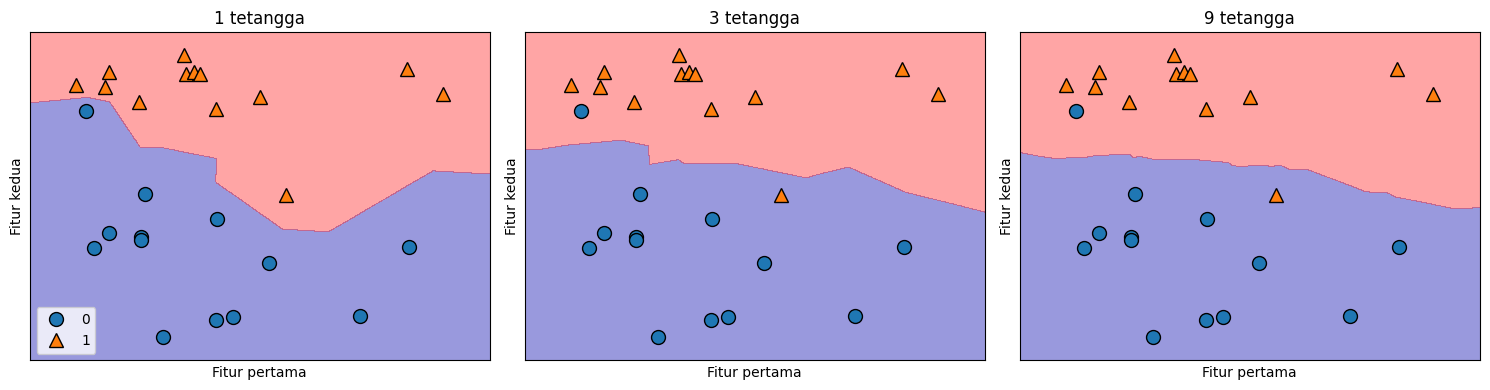

In [11]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for jumlah_tetangga, axis in zip(
    [1, 3, 9],
    axes
):
    model = KNeighborsClassifier(
        n_neighbors=jumlah_tetangga
    )

    model.fit(
        X_forge,
        y_forge
    )

    mglearn.plots.plot_2d_separator(
        model,
        X_forge,
        fill=True,
        eps=0.5,
        ax=axis,
        alpha=0.4
    )

    mglearn.discrete_scatter(
        X_forge[:, 0],
        X_forge[:, 1],
        y_forge,
        ax=axis
    )

    axis.set_title(
        f"{jumlah_tetangga} tetangga"
    )

    axis.set_xlabel(
        "Fitur pertama"
    )

    axis.set_ylabel(
        "Fitur kedua"
    )

axes[0].legend(
    loc=3
)

plt.tight_layout()
plt.show()

### Analisis Batas Keputusan

Ketika `n_neighbors=1`, batas keputusan terlihat lebih kompleks karena
model mengikuti setiap data training secara dekat. Model seperti ini
berpotensi mengalami overfitting.

Ketika jumlah tetangga ditambah, batas keputusan menjadi lebih halus.
Model mempertimbangkan lebih banyak data sebelum menentukan kelas.

Jumlah tetangga yang terlalu besar juga dapat membuat model menjadi
terlalu sederhana dan berpotensi mengalami underfitting.

## 7. KNN pada Breast Cancer Dataset

Breast Cancer Wisconsin Dataset merupakan dataset classification yang
digunakan untuk memprediksi apakah tumor bersifat malignant atau benign.

Dataset ini memiliki dua kelas:

- Malignant, yaitu tumor ganas.
- Benign, yaitu tumor jinak.

In [12]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print("Keys:", cancer.keys())
print("Ukuran data:", cancer.data.shape)
print("Nama kelas:", cancer.target_names)
print("Jumlah fitur:", len(cancer.feature_names))

Keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Ukuran data: (569, 30)
Nama kelas: ['malignant' 'benign']
Jumlah fitur: 30


In [13]:
jumlah_per_kelas = {
    nama_kelas: jumlah
    for nama_kelas, jumlah in zip(
        cancer.target_names,
        np.bincount(cancer.target)
    )
}

print("Jumlah data per kelas:")
print(jumlah_per_kelas)

Jumlah data per kelas:
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=66
)

training_accuracy = []
testing_accuracy = []

neighbors_settings = range(1, 11)

for jumlah_tetangga in neighbors_settings:
    model = KNeighborsClassifier(
        n_neighbors=jumlah_tetangga
    )

    model.fit(
        X_train,
        y_train
    )

    training_accuracy.append(
        model.score(X_train, y_train)
    )

    testing_accuracy.append(
        model.score(X_test, y_test)
    )

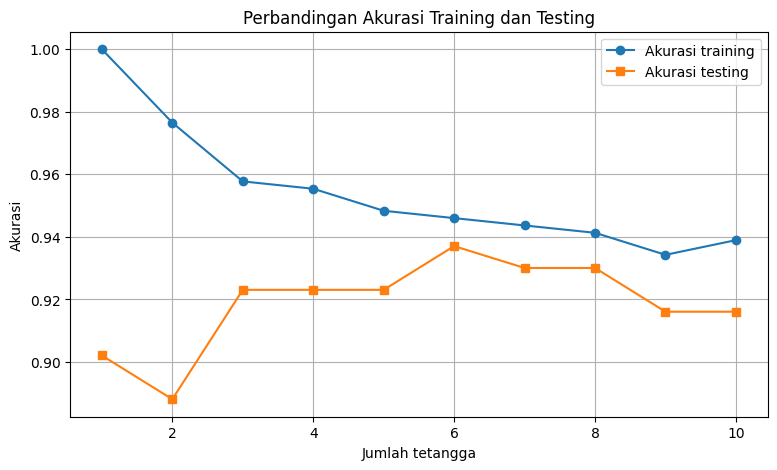

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    neighbors_settings,
    training_accuracy,
    label="Akurasi training",
    marker="o"
)

plt.plot(
    neighbors_settings,
    testing_accuracy,
    label="Akurasi testing",
    marker="s"
)

plt.ylabel("Akurasi")
plt.xlabel("Jumlah tetangga")
plt.title("Perbandingan Akurasi Training dan Testing")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
hasil_knn = pd.DataFrame({
    "n_neighbors": list(neighbors_settings),
    "training_accuracy": training_accuracy,
    "testing_accuracy": testing_accuracy
})

hasil_knn

,n_neighbors,training_accuracy,testing_accuracy
0,1,1.000000,0.902098
1,2,0.976526,0.888112
2,3,0.957746,0.923077
3,4,0.955399,0.923077
4,5,0.948357,0.923077
5,6,0.946009,0.937063
6,7,0.943662,0.930070
7,8,0.941315,0.930070
8,9,0.934272,0.916084
9,10,0.938967,0.916084


In [17]:
indeks_terbaik = np.argmax(testing_accuracy)

tetangga_terbaik = list(
    neighbors_settings
)[indeks_terbaik]

akurasi_terbaik = testing_accuracy[
    indeks_terbaik
]

print(
    "Jumlah tetangga terbaik:",
    tetangga_terbaik
)

print(
    f"Akurasi testing terbaik: "
    f"{akurasi_terbaik:.3f}"
)

Jumlah tetangga terbaik: 6
Akurasi testing terbaik: 0.937


### Analisis KNN pada Breast Cancer Dataset

Grafik memperlihatkan hubungan antara jumlah tetangga dengan akurasi
training dan testing.

Pada jumlah tetangga yang sangat kecil, akurasi training cenderung lebih
tinggi karena model mengikuti data training secara lebih dekat. Kondisi
ini dapat menunjukkan kecenderungan overfitting.

Ketika jumlah tetangga bertambah, model menjadi lebih sederhana.
Jumlah tetangga terbaik dipilih berdasarkan akurasi testing tertinggi,
bukan hanya berdasarkan akurasi training.

## 8. K-Nearest Neighbors Regression

KNN regression digunakan untuk memprediksi target berupa angka kontinu.

Model mencari sejumlah data training terdekat dari data baru. Hasil
prediksi kemudian diperoleh dengan menghitung rata-rata nilai target
dari tetangga-tetangga tersebut.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_wave,
    y_wave,
    test_size=0.25,
    random_state=0
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

Ukuran X_train: (30, 1)
Ukuran X_test : (10, 1)


In [19]:
knn_regressor = KNeighborsRegressor(
    n_neighbors=3
)

knn_regressor.fit(
    X_train,
    y_train
)

print("Model KNN regressor berhasil dilatih.")

Model KNN regressor berhasil dilatih.


In [20]:
prediksi_regression = knn_regressor.predict(
    X_test
)

print("Hasil prediksi:")
print(prediksi_regression)

print("\nTarget sebenarnya:")
print(y_test)

Hasil prediksi:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]

Target sebenarnya:
[ 0.37299129  0.21778193  0.96695428 -1.38773632 -1.05979555 -0.90496988
  0.43655826  0.7789638  -0.54114599 -0.95652133]


In [21]:
r2_score = knn_regressor.score(
    X_test,
    y_test
)

print(
    f"Nilai R²: {r2_score:.3f}"
)

Nilai R²: 0.834


### Penjelasan Nilai R²

Kinerja model regression dievaluasi menggunakan nilai R².

- R² mendekati 1 menunjukkan model dapat menjelaskan sebagian besar
  variasi data.
- R² mendekati 0 menunjukkan performa model mendekati prediksi
  menggunakan nilai rata-rata.
- R² negatif menunjukkan model bekerja lebih buruk daripada prediksi
  menggunakan nilai rata-rata.

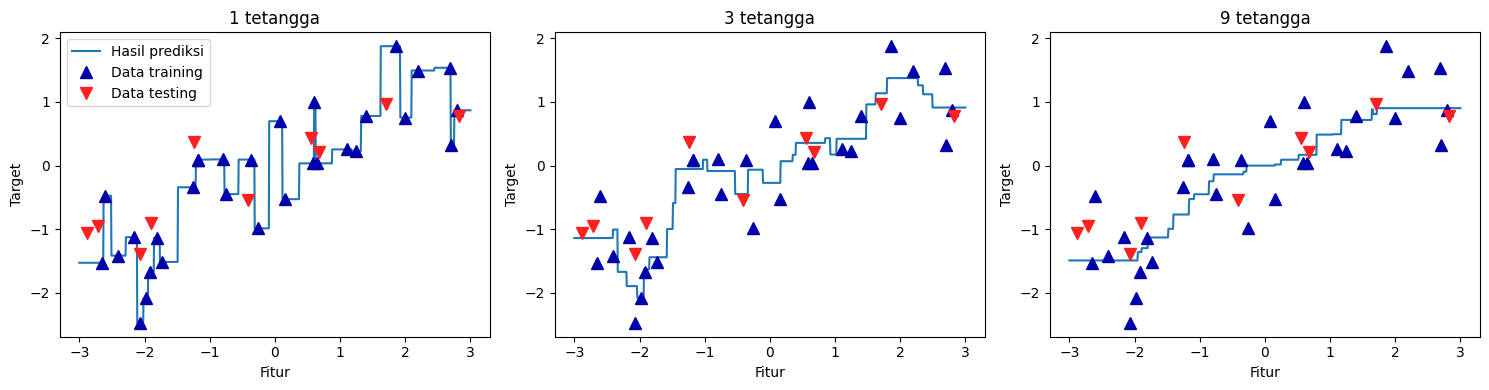

In [22]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

garis = np.linspace(
    -3,
    3,
    1000
).reshape(-1, 1)

for jumlah_tetangga, axis in zip(
    [1, 3, 9],
    axes
):
    model = KNeighborsRegressor(
        n_neighbors=jumlah_tetangga
    )

    model.fit(
        X_train,
        y_train
    )

    axis.plot(
        garis,
        model.predict(garis),
        label="Hasil prediksi"
    )

    axis.plot(
        X_train,
        y_train,
        "^",
        c=mglearn.cm2(0),
        markersize=8,
        label="Data training"
    )

    axis.plot(
        X_test,
        y_test,
        "v",
        c=mglearn.cm2(1),
        markersize=8,
        label="Data testing"
    )

    axis.set_title(
        f"{jumlah_tetangga} tetangga"
    )

    axis.set_xlabel(
        "Fitur"
    )

    axis.set_ylabel(
        "Target"
    )

axes[0].legend(
    loc="best"
)

plt.tight_layout()
plt.show()

### Analisis KNN Regression

Pada `n_neighbors=1`, prediksi sangat mengikuti data training sehingga
garis prediksi terlihat tidak halus. Model seperti ini lebih kompleks
dan dapat mengalami overfitting.

Ketika jumlah tetangga bertambah, hasil prediksi menjadi lebih halus
karena nilai target dihitung berdasarkan rata-rata lebih banyak
tetangga.

Jika jumlah tetangga terlalu besar, model dapat menjadi terlalu
sederhana dan berpotensi mengalami underfitting.

## 9. Kesimpulan Sementara

Pada bagian pertama Chapter 2, saya mempelajari perbedaan classification
dan regression serta konsep generalization, overfitting, dan
underfitting.

Saya juga mengimplementasikan K-Nearest Neighbors untuk classification
dan regression. Jumlah tetangga memengaruhi kompleksitas model. Jumlah
tetangga yang terlalu sedikit dapat meningkatkan risiko overfitting,
sedangkan jumlah tetangga yang terlalu besar dapat menyebabkan
underfitting.

Pemilihan parameter harus mempertimbangkan performa pada data testing,
bukan hanya data training.